In [76]:
!pip install plotly openpyxl -q

## Resources

This analysis utilizes the `ds1_grades.csv` dataset, which contains student performance metrics. The dataset includes information such as student scores, attendance percentages, assignment averages, and exam scores. It serves as the foundation for exploring academic trends, identifying influencing factors, and assessing overall student success.

In [77]:
import pandas as pd
import numpy as np
import os

print('✅ Libraries imported!')

✅ Libraries imported!


In [78]:
from google.colab import files
uploaded = files.upload()

Saving ds1_grades.csv to ds1_grades (2).csv


In [79]:
df_grades = pd.read_csv('ds1_grades.csv')
display(df_grades.head())

,student_id,course_id,score,attendance_pct,year,semester,assignment_avg,exam_score
0,STU0001,CRS002,71.3,77.7,2022,Sem 1,69.2,74.9
1,STU0001,CRS008,55.2,57.9,2023,Sem 2,56.4,33.6
2,STU0001,CRS010,57.7,59.8,2024,Sem 2,59.3,59.7
3,STU0001,CRS001,54.7,74.0,2023,Sem 1,70.8,46.1
4,STU0001,CRS011,77.2,82.4,2022,Sem 1,80.0,100.0


In [80]:
display(df_grades.describe())

,score,attendance_pct,year,assignment_avg,exam_score
count,890.000000,895.000000,905.000000,905.000000,905.000000
mean,62.408202,75.031397,2023.032044,64.528398,59.635580
std,18.325335,14.679693,0.833528,15.030490,20.193491
min,9.300000,21.300000,2022.000000,13.000000,0.000000
25%,50.900000,65.200000,2022.000000,54.500000,46.400000
50%,62.100000,75.500000,2023.000000,65.200000,60.200000
75%,74.200000,86.050000,2024.000000,74.600000,74.900000
max,100.000000,100.000000,2024.000000,100.000000,100.000000


Data Exploration

In [81]:
# How many rows and columns does your main dataset have?
rows, cols = df_grades.shape
print(f"The dataset has {rows} rows and {cols} columns.")

The dataset has 905 rows and 8 columns.


The first 5 rows of the dataset have already been displayed above.

In [82]:
# What are the column names and data types?
print("Column names and data types:")
df_grades.info()

Column names and data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 905 entries, 0 to 904
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   student_id      905 non-null    object 
 1   course_id       905 non-null    object 
 2   score           890 non-null    float64
 3   attendance_pct  895 non-null    float64
 4   year            905 non-null    int64  
 5   semester        905 non-null    object 
 6   assignment_avg  905 non-null    float64
 7   exam_score      905 non-null    float64
dtypes: float64(4), int64(1), object(3)
memory usage: 56.7+ KB


Basic statistics for numeric columns (min, max, mean, std) have already been displayed above using `df_grades.describe()`.

In [83]:
# How many missing values are in each column? Show both the count AND the percentage.
missing_counts = df_grades.isnull().sum()
missing_percentages = (df_grades.isnull().sum() / len(df_grades)) * 100

missing_info = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percentage (%)': missing_percentages
})

display(missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False))

,Missing Count,Missing Percentage (%)
score,15,1.657459
attendance_pct,10,1.104972


 Unique values for categorical columns

In [84]:
# Show the unique values for at least 3 categorical columns.
print("Unique values for 'course_id':")
print(df_grades['course_id'].unique())
print("\nUnique values for 'semester':")
print(df_grades['semester'].unique())
print("\nUnique values for 'year':")
print(df_grades['year'].unique())

Unique values for 'course_id':
['CRS002' 'CRS008' 'CRS010' 'CRS001' 'CRS011' 'CRS012' 'CRS005' 'CRS003'
 'CRS004' 'CRS009' 'CRS006' 'CRS007']

Unique values for 'semester':
['Sem 1' 'Sem 2']

Unique values for 'year':
[2022 2023 2024]


The df_grades dataset contains 905 rows and 8 columns, including score, attendance_pct, assignment_avg, exam_score as numerical types, and student_id, course_id, semester as object types.

Missing values were identified in two columns: score (15 values, or 1.66%) and attendance_pct (10 values, or 1.10%). Categorical columns such as course_id, semester, and year were inspected for unique values, revealing distinct categories.
Main columns for analysis: The primary columns that will be used for analyzing student performance and identifying influencing factors are score, attendance_pct, assignment_avg, and exam_score. student_id, course_id, year, and semester will also be crucial for contextualizing the performance data.

## Handle Missing Values

In [85]:
# Fill missing values in 'score' with the mean of the column
df_grades['score'].fillna(df_grades['score'].mean(), inplace=True)

# Fill missing values in 'attendance_pct' with the mean of the column
df_grades['attendance_pct'].fillna(df_grades['attendance_pct'].mean(), inplace=True)

print("Missing values filled successfully.")
display(df_grades.head())

# Verify that there are no more missing values in these columns
print("\nMissing values after filling:")
missing_counts_after = df_grades.isnull().sum()
missing_percentages_after = (df_grades.isnull().sum() / len(df_grades)) * 100

missing_info_after = pd.DataFrame({
    'Missing Count': missing_counts_after,
    'Missing Percentage (%)': missing_percentages_after
})

display(missing_info_after[missing_info_after['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False))

Missing values filled successfully.


/tmp/ipykernel_15095/798942957.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_grades['score'].fillna(df_grades['score'].mean(), inplace=True)
/tmp/ipykernel_15095/798942957.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, in

,student_id,course_id,score,attendance_pct,year,semester,assignment_avg,exam_score
0,STU0001,CRS002,71.3,77.7,2022,Sem 1,69.2,74.9
1,STU0001,CRS008,55.2,57.9,2023,Sem 2,56.4,33.6
2,STU0001,CRS010,57.7,59.8,2024,Sem 2,59.3,59.7
3,STU0001,CRS001,54.7,74.0,2023,Sem 1,70.8,46.1
4,STU0001,CRS011,77.2,82.4,2022,Sem 1,80.0,100.0



Missing values after filling:


,Missing Count,Missing Percentage (%)


 Duplicate Rows

First, let's check for and remove any duplicate rows in the dataset to ensure each record is unique.

In [86]:
# Check for duplicate rows
duplicate_rows = df_grades.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_rows}")

# Remove duplicate rows if any exist
if duplicate_rows > 0:
    df_grades.drop_duplicates(inplace=True)
    print(f"Duplicate rows removed. New dataset shape: {df_grades.shape}")
else:
    print("No duplicate rows found.")

Number of duplicate rows found: 0
No duplicate rows found.


Missing Values Justification

As previously handled, missing values in score and attendance_pct were filled with the mean of their respective columns. This approach was chosen to preserve the dataset's size and the overall distribution of these variables, which are critical for performance analysis. Mean imputation is a simple and effective strategy when the percentage of missing data is relatively small (1.10% and 1.66% respectively), preventing significant bias or loss of information that dropping these rows might cause.

Invalid Values

Next, we'll check for logically impossible values in numerical columns like score, attendance_pct, assignment_avg, and exam_score. We'll assume these should be between 0 and 100.

In [87]:
# Define columns to check for invalid values (e.g., negative or above 100)
numerical_cols = ['score', 'attendance_pct', 'assignment_avg', 'exam_score']

for col in numerical_cols:
    # Check for values less than 0
    invalid_low = df_grades[df_grades[col] < 0].shape[0]
    if invalid_low > 0:
        print(f"Found {invalid_low} invalid values (less than 0) in '{col}'. Correcting them to 0.")
        df_grades.loc[df_grades[col] < 0, col] = 0

    # Check for values greater than 100 (assuming 100 is max for scores/percentages)
    invalid_high = df_grades[df_grades[col] > 100].shape[0]
    if invalid_high > 0:
        print(f"Found {invalid_high} invalid values (greater than 100) in '{col}'. Correcting them to 100.")
        df_grades.loc[df_grades[col] > 100, col] = 100

print("Invalid values checking and correction complete.")

Invalid values checking and correction complete.


Inconsistent Text (Categorical Data Standardisation)



In [88]:
categorical_cols = ['course_id', 'semester'] # 'year' is numerical and consistent

for col in categorical_cols:
    # Convert to string and apply .strip() to remove leading/trailing whitespace
    df_grades[col] = df_grades[col].astype(str).str.strip()
    # Convert to title case to standardize (e.g., 'sem 1' -> 'Sem 1' if not already)
    df_grades[col] = df_grades[col].apply(lambda x: x.title() if isinstance(x, str) else x)

    print(f"Unique values for '{col}' after standardization: {df_grades[col].unique()}")

print("Categorical data standardization complete.")

Unique values for 'course_id' after standardization: ['Crs002' 'Crs008' 'Crs010' 'Crs001' 'Crs011' 'Crs012' 'Crs005' 'Crs003'
 'Crs004' 'Crs009' 'Crs006' 'Crs007']
Unique values for 'semester' after standardization: ['Sem 1' 'Sem 2']
Categorical data standardization complete.


Data Types


In [89]:
print("Current data types:")
df_grades.info()
print("Data types verified. No changes needed as they are already appropriate.")

Current data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 905 entries, 0 to 904
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   student_id      905 non-null    object 
 1   course_id       905 non-null    object 
 2   score           905 non-null    float64
 3   attendance_pct  905 non-null    float64
 4   year            905 non-null    int64  
 5   semester        905 non-null    object 
 6   assignment_avg  905 non-null    float64
 7   exam_score      905 non-null    float64
dtypes: float64(4), int64(1), object(3)
memory usage: 56.7+ KB
Data types verified. No changes needed as they are already appropriate.


New Derived Columns



In [90]:
# Function to assign a grade letter
def assign_grade_letter(score):
    if score >= 90: return 'A'
    elif score >= 80: return 'B'
    elif score >= 70: return 'C'
    elif score >= 60: return 'D'
    else: return 'F'

# Create 'grade_letter' column
df_grades['grade_letter'] = df_grades['score'].apply(assign_grade_letter)

# Create 'passed' column
df_grades['passed'] = df_grades['score'] >= 50

print("New derived columns 'grade_letter' and 'passed' created.")

New derived columns 'grade_letter' and 'passed' created.


Verify the Cleaned Dataset


In [91]:
print(f"Shape of the cleaned dataset: {df_grades.shape}")

print("\nMissing values in the cleaned dataset:")
display(df_grades.isnull().sum().to_frame(name='Missing Count'))

print("\nFirst 5 rows of the cleaned dataset with new columns:")
display(df_grades.head())

Shape of the cleaned dataset: (905, 10)

Missing values in the cleaned dataset:


,Missing Count
student_id,0
course_id,0
score,0
attendance_pct,0
year,0
semester,0
assignment_avg,0
exam_score,0
grade_letter,0
passed,0



First 5 rows of the cleaned dataset with new columns:


,student_id,course_id,score,attendance_pct,year,semester,assignment_avg,exam_score,grade_letter,passed
0,STU0001,Crs002,71.3,77.7,2022,Sem 1,69.2,74.9,C,True
1,STU0001,Crs008,55.2,57.9,2023,Sem 2,56.4,33.6,F,True
2,STU0001,Crs010,57.7,59.8,2024,Sem 2,59.3,59.7,F,True
3,STU0001,Crs001,54.7,74.0,2023,Sem 1,70.8,46.1,F,True
4,STU0001,Crs011,77.2,82.4,2022,Sem 1,80.0,100.0,C,True


 Top 10 Best Performing Students

Identifying the top 10 students by their overall score to highlight high achievers.

In [92]:
# Sort by 'score' in descending order to get the best performing students
top_10_students = df_grades.sort_values(by='score', ascending=False).head(10)

# Display their student_id and key performance columns
display(top_10_students[['student_id', 'score', 'attendance_pct', 'assignment_avg', 'exam_score', 'grade_letter', 'passed']])

,student_id,score,attendance_pct,assignment_avg,exam_score,grade_letter,passed
308,STU0069,100.0,61.3,69.7,68.1,A,True
861,STU0191,100.0,61.8,72.5,77.8,A,True
864,STU0192,100.0,74.0,54.5,55.5,A,True
255,STU0058,100.0,65.4,80.3,69.3,A,True
763,STU0170,100.0,79.5,80.6,41.8,A,True
792,STU0177,100.0,82.7,60.5,47.4,A,True
796,STU0178,100.0,90.9,72.1,45.9,A,True
813,STU0181,100.0,77.7,69.1,82.8,A,True
787,STU0176,100.0,68.0,86.0,52.0,A,True
39,STU0009,100.0,89.4,76.1,63.7,A,True


 Bottom 10 Lowest Performing Students

Identifying the bottom 10 students by their overall score to highlight those who may need additional support.

In [93]:
# Sort by 'score' in ascending order to get the lowest performing students
bottom_10_students = df_grades.sort_values(by='score', ascending=True).head(10)

# Display their student_id and key performance columns
display(bottom_10_students[['student_id', 'score', 'attendance_pct', 'assignment_avg', 'exam_score', 'grade_letter', 'passed']])

,student_id,score,attendance_pct,assignment_avg,exam_score,grade_letter,passed
277,STU0063,9.3,100.0,65.3,36.6,F,False
632,STU0142,10.6,68.5,74.5,57.7,F,False
829,STU0184,12.0,59.5,39.7,48.3,F,False
279,STU0063,14.3,95.3,47.7,100.0,F,False
599,STU0134,14.9,55.6,57.8,82.0,F,False
500,STU0113,15.7,70.4,67.2,49.6,F,False
379,STU0085,16.0,77.1,62.3,63.2,F,False
666,STU0150,17.0,79.7,62.7,81.2,F,False
23,STU0005,17.9,98.4,77.0,56.1,F,False
581,STU0131,18.4,55.6,57.7,91.8,F,False


 Students Who Failed (Score Below 50)

Let's identify all students whose score is less than 50, which corresponds to passed == False.

In [94]:
# Filter for students who failed (score < 50, or 'passed' column is False)
failed_students = df_grades[df_grades['passed'] == False]

# Count the number of failing students
num_failed_students = failed_students.shape[0]

# Calculate the percentage of failing students
total_students = df_grades.shape[0]
percentage_failed = (num_failed_students / total_students) * 100

print(f"Number of students who failed: {num_failed_students}")
print(f"Percentage of total students who failed: {percentage_failed:.2f}%")

# Display the DataFrame of failing students
display(failed_students[['student_id', 'score', 'attendance_pct', 'assignment_avg', 'exam_score', 'grade_letter', 'passed']])

Number of students who failed: 215
Percentage of total students who failed: 23.76%


,student_id,score,attendance_pct,assignment_avg,exam_score,grade_letter,passed
8,STU0002,45.3,78.6,69.0,72.8,F,False
23,STU0005,17.9,98.4,77.0,56.1,F,False
25,STU0005,48.7,72.5,68.9,81.0,F,False
31,STU0006,46.9,68.3,65.7,59.0,F,False
32,STU0007,34.3,52.7,64.7,67.9,F,False
...,...,...,...,...,...,...,...
860,STU0191,44.0,97.1,76.5,74.6,F,False
879,STU0196,41.5,87.3,45.9,83.1,F,False
884,STU0197,24.1,82.3,58.5,27.1,F,False
891,STU0198,31.1,78.5,62.6,74.2,F,False


 Students Who Passed with High Attendance

Let's filter for students who have passed (score >= 50) and also have an attendance_pct greater than 80%.

In [95]:
# Filter for students who passed (score >= 50) AND have an attendance percentage > 80%
high_achievers_high_attendance = df_grades[(df_grades['passed'] == True) & (df_grades['attendance_pct'] > 80)]

# How many are there?
num_students = high_achievers_high_attendance.shape[0]
print(f"Number of students who passed with attendance > 80%: {num_students}")

# What percentage of the total is that?
total_students = df_grades.shape[0]
percentage_of_total = (num_students / total_students) * 100
print(f"Percentage of total students: {percentage_of_total:.2f}%")

# Display their details
display(high_achievers_high_attendance[['student_id', 'score', 'attendance_pct', 'assignment_avg', 'exam_score', 'grade_letter', 'passed']])

Number of students who passed with attendance > 80%: 258
Percentage of total students: 28.51%


,student_id,score,attendance_pct,assignment_avg,exam_score,grade_letter,passed
4,STU0001,77.2,82.4,80.0,100.0,C,True
9,STU0002,73.8,100.0,55.2,23.4,C,True
10,STU0002,71.2,95.6,96.6,37.7,C,True
15,STU0003,79.3,100.0,57.7,75.5,C,True
18,STU0004,66.8,82.6,80.8,40.4,D,True
...,...,...,...,...,...,...,...
892,STU0198,57.4,88.0,49.2,58.7,F,True
895,STU0199,55.8,92.4,60.6,67.7,F,True
896,STU0199,72.9,85.8,77.4,45.1,C,True
900,STU0200,83.2,81.1,66.0,29.5,B,True


Students Who Passed with Low Attendance

Let's identify students who successfully passed (score >= 50) but had a relatively low attendance percentage (e.g., less than 60%). This could highlight students who are able to maintain good academic performance even without very high attendance.

In [96]:
# Identify students who passed (score >= 50) AND had an attendance percentage less than 60%
passed_low_attendance = df_grades[(df_grades['passed'] == True) & (df_grades['attendance_pct'] < 60)]

# Count the number of such students
num_passed_low_attendance = passed_low_attendance.shape[0]

# Calculate the percentage of such students out of the total
total_students = df_grades.shape[0]
percentage_of_total_passed_low_attendance = (num_passed_low_attendance / total_students) * 100

print(f"Number of students who passed with attendance < 60%: {num_passed_low_attendance}")
print(f"Percentage of total students: {percentage_of_total_passed_low_attendance:.2f}%")

# Display their details
display(passed_low_attendance[['student_id', 'score', 'attendance_pct', 'assignment_avg', 'exam_score', 'grade_letter', 'passed']])

Number of students who passed with attendance < 60%: 103
Percentage of total students: 11.38%


,student_id,score,attendance_pct,assignment_avg,exam_score,grade_letter,passed
1,STU0001,55.2,57.9,56.4,33.6,F,True
2,STU0001,57.7,59.8,59.3,59.7,F,True
26,STU0005,51.9,55.1,87.4,69.1,F,True
27,STU0006,57.4,56.8,68.4,17.7,F,True
46,STU0010,70.5,47.2,90.9,73.4,C,True
...,...,...,...,...,...,...,...
868,STU0194,100.0,47.9,61.9,69.3,A,True
881,STU0196,69.9,58.8,40.6,26.8,D,True
890,STU0198,69.8,44.9,67.7,43.3,D,True
894,STU0199,56.5,51.8,68.8,25.5,F,True


Average Score and Student Count by Course

Let's analyze the average score and the number of students for each course to understand performance across different programs.

In [97]:
# Group by 'course_id' and calculate the average score and count of students
course_performance = df_grades.groupby('course_id').agg(
    average_score=('score', 'mean'),
    student_count=('student_id', 'nunique') # Use nunique to count unique students per course
).reset_index()

# Sort the results by 'average_score' in descending order
course_performance_sorted = course_performance.sort_values(by='average_score', ascending=False)

display(course_performance_sorted)

,course_id,average_score,student_count
3,Crs004,64.890323,62
11,Crs012,64.668878,64
5,Crs006,64.123819,85
4,Crs005,63.926932,56
6,Crs007,63.863889,72
0,Crs001,62.949427,73
1,Crs002,62.046172,85
7,Crs008,61.692413,78
10,Crs011,61.639449,94
9,Crs010,61.639124,82


Average Score and Attendance by Year and Semester

Let's analyze how student performance score and engagement attendance_pct vary across different academic years and semesters.

In [98]:
# Group by 'year' and 'semester' and calculate the average score and attendance percentage
performance_by_period = df_grades.groupby(['year', 'semester']).agg(
    average_score=('score', 'mean'),
    average_attendance=('attendance_pct', 'mean')
).reset_index()

# Sort the results for better readability
performance_by_period_sorted = performance_by_period.sort_values(by=['year', 'semester'])

display(performance_by_period_sorted)

,year,semester,average_score,average_attendance
0,2022,Sem 1,61.969403,75.963229
1,2022,Sem 2,62.746370,72.600204
2,2023,Sem 1,64.874531,76.805554
3,2023,Sem 2,64.879579,74.315894
4,2024,Sem 1,59.758838,75.542615
5,2024,Sem 2,60.991513,75.276985


In [102]:
from google.colab import files
import io
import pandas as pd

print("Please upload the 'ds1_courses.csv' file:")
uploaded_files = files.upload()

# Check if 'ds1_courses.csv' was among the uploaded files
courses_filename = None
for fname in uploaded_files.keys():
    if 'ds1_courses.csv' in fname:
        courses_filename = fname
        break

if courses_filename:
    df_courses = pd.read_csv(io.BytesIO(uploaded_files[courses_filename]))
    print(f"\n'{courses_filename}' uploaded and loaded successfully. First 5 rows of df_courses:")
    display(df_courses.head())
else:
    print("Error: 'ds1_courses.csv' (or a similarly named file) was not found in the uploaded files. Please ensure you upload the correct file.")
    # Clear df_courses if it holds incorrect data
    if 'df_courses' in locals():
        del df_courses


Please upload the 'ds1_courses.csv' file:


Saving ds1_students.csv to ds1_students (9).csv
Error: 'ds1_courses.csv' (or a similarly named file) was not found in the uploaded files. Please ensure you upload the correct file.


Merge df_grades with df_students

Now, let's merge the df_grades and df_students DataFrames on the common column student_id. This will combine the grade information with student demographic data. We'll use a left merge to keep all records from df_grades.

In [103]:
# Option A: Merge students + grades + courses into one DataFrame
#           so you can see student name, course name, and score together

if 'df_students' in locals() and not df_students.empty:
    df_merged = pd.merge(df_grades, df_students, on='student_id', how='left')

    print("Shape of the merged DataFrame:", df_merged.shape)
    print("First 5 rows of the merged DataFrame:")
    display(df_merged.head())
else:
    print("df_students DataFrame is not available for merging. Please ensure 'ds1_students.csv' was uploaded and loaded correctly.")

Shape of the merged DataFrame: (905, 22)
First 5 rows of the merged DataFrame:


,student_id,course_id,score,attendance_pct,year,semester,assignment_avg,exam_score,grade_letter,passed,...,gender,region,program,level,mode,status,scholarship,enrollment_year,age,tuition_fee_ghs
0,STU0001,Crs002,71.3,77.7,2022,Sem 1,69.2,74.9,C,True,...,Female,Northern,Accounting,300,Full-Time,Active,No,2023,28,11000
1,STU0001,Crs008,55.2,57.9,2023,Sem 2,56.4,33.6,F,True,...,Female,Northern,Accounting,300,Full-Time,Active,No,2023,28,11000
2,STU0001,Crs010,57.7,59.8,2024,Sem 2,59.3,59.7,F,True,...,Female,Northern,Accounting,300,Full-Time,Active,No,2023,28,11000
3,STU0001,Crs001,54.7,74.0,2023,Sem 1,70.8,46.1,F,True,...,Female,Northern,Accounting,300,Full-Time,Active,No,2023,28,11000
4,STU0001,Crs011,77.2,82.4,2022,Sem 1,80.0,100.0,C,True,...,Female,Northern,Accounting,300,Full-Time,Active,No,2023,28,11000


In [99]:
if 'df_students' in locals() and not df_students.empty:
    # Standardize the 'gender' column to 'Female' or 'Male'
    df_students['gender'] = df_students['gender'].astype(str).str.lower().map({'female': 'Female', 'male': 'Male', 'f': 'Female', 'm': 'Male'})
    print("Gender column in df_students standardized.")
    display(df_students['gender'].value_counts())
else:
    print("df_students DataFrame is not available for gender standardization.")

# Re-run the merge and pivot table cells to reflect the changes.
# Assuming df_merged and df_final_merged will be re-created and pivot table re-calculated.


Gender column in df_students standardized.


,count
gender,
Female,108
Male,92


Merging DataFrames and Generating Pivot Table

After standardizing the gender column in df_students, we need to re-run the merge operations to ensure df_merged and df_final_merged incorporate these changes. Finally, we will regenerate the pivot table to reflect the corrected gender categories for a cleaner analysis.

In [100]:
# Re-run the merge of df_grades and df_students to update df_merged
if 'df_grades' in locals() and not df_grades.empty and 'df_students' in locals() and not df_students.empty:
    df_merged = pd.merge(df_grades, df_students, on='student_id', how='left')
    print("df_merged re-created with standardized gender.")
    display(df_merged.head())
else:
    print("Error: Unable to re-create df_merged. Check if df_grades or df_students are available.")

# Re-run Option B to create df_final_merged with program average
if 'df_merged' in locals() and not df_merged.empty and 'program' in df_merged.columns and 'score' in df_merged.columns:
    school_avg_scores = df_merged.groupby('program')['score'].mean().reset_index()
    school_avg_scores.rename(columns={'score': 'program_avg_score'}, inplace=True)
    df_final_merged = pd.merge(df_merged, school_avg_scores, on='program', how='left')
    print("df_final_merged re-created with program average.")
    display(df_final_merged.head())
else:
    print("Error: Unable to re-create df_final_merged. Check if df_merged or required columns are available.")

# Re-run the pivot table creation
if 'df_final_merged' in locals() and not df_final_merged.empty:
    pivot_table_gender_program = df_final_merged.pivot_table(
        values='score',
        index='program',
        columns='gender',
        aggfunc='mean'
    )

    print("\nUpdated Pivot Table: Average Score by Program and Gender")
    display(pivot_table_gender_program)
else:
    print("Error: 'df_final_merged' DataFrame is not available for pivot table creation.")

df_merged re-created with standardized gender.


,student_id,course_id,score,attendance_pct,year,semester,assignment_avg,exam_score,grade_letter,passed,...,gender,region,program,level,mode,status,scholarship,enrollment_year,age,tuition_fee_ghs
0,STU0001,Crs002,71.3,77.7,2022,Sem 1,69.2,74.9,C,True,...,Female,Northern,Accounting,300,Full-Time,Active,No,2023,28,11000
1,STU0001,Crs008,55.2,57.9,2023,Sem 2,56.4,33.6,F,True,...,Female,Northern,Accounting,300,Full-Time,Active,No,2023,28,11000
2,STU0001,Crs010,57.7,59.8,2024,Sem 2,59.3,59.7,F,True,...,Female,Northern,Accounting,300,Full-Time,Active,No,2023,28,11000
3,STU0001,Crs001,54.7,74.0,2023,Sem 1,70.8,46.1,F,True,...,Female,Northern,Accounting,300,Full-Time,Active,No,2023,28,11000
4,STU0001,Crs011,77.2,82.4,2022,Sem 1,80.0,100.0,C,True,...,Female,Northern,Accounting,300,Full-Time,Active,No,2023,28,11000


df_final_merged re-created with program average.


,student_id,course_id,score,attendance_pct,year,semester,assignment_avg,exam_score,grade_letter,passed,...,region,program,level,mode,status,scholarship,enrollment_year,age,tuition_fee_ghs,program_avg_score
0,STU0001,Crs002,71.3,77.7,2022,Sem 1,69.2,74.9,C,True,...,Northern,Accounting,300,Full-Time,Active,No,2023,28,11000,61.162016
1,STU0001,Crs008,55.2,57.9,2023,Sem 2,56.4,33.6,F,True,...,Northern,Accounting,300,Full-Time,Active,No,2023,28,11000,61.162016
2,STU0001,Crs010,57.7,59.8,2024,Sem 2,59.3,59.7,F,True,...,Northern,Accounting,300,Full-Time,Active,No,2023,28,11000,61.162016
3,STU0001,Crs001,54.7,74.0,2023,Sem 1,70.8,46.1,F,True,...,Northern,Accounting,300,Full-Time,Active,No,2023,28,11000,61.162016
4,STU0001,Crs011,77.2,82.4,2022,Sem 1,80.0,100.0,C,True,...,Northern,Accounting,300,Full-Time,Active,No,2023,28,11000,61.162016



Updated Pivot Table: Average Score by Program and Gender


gender,Female,Male
program,,
Accounting,58.915400,62.992593
Business Admin,62.339726,62.793681
Computer Science,64.238222,59.254351
Education,62.396086,60.853035
Engineering,63.523636,61.951613
Nursing,62.397101,66.836923


In [ ]:
import pandas as pd

# Option B: Create a school-level summary DataFrame (avg score per school)
#           then merge it back into the main pupils DataFrame
#           so each row has the school average next to the individual score

# Assuming 'program' in df_merged (derived from df_students) represents the 'school' level for this summary.
# Check if df_merged is available and contains 'program' and 'score' columns
if 'df_merged' in locals() and not df_merged.empty and 'program' in df_merged.columns and 'score' in df_merged.columns:
    # Calculate average score per program (school-level summary)
    school_avg_scores = df_merged.groupby('program')['score'].mean().reset_index()
    school_avg_scores.rename(columns={'score': 'program_avg_score'}, inplace=True)

    # Merge the school-level summary back into the main df_merged
    # The new DataFrame will be df_final_merged
    df_final_merged = pd.merge(df_merged, school_avg_scores, on='program', how='left')

    print("Shape of the final merged DataFrame (with program average):")
    print(df_final_merged.shape)
    print("First 5 rows of the final merged DataFrame (with program average):")
    display(df_final_merged.head())
else:
    print("Error: The 'df_merged' DataFrame or required columns ('program', 'score') are not available for Option B.")
    print("Please ensure 'df_grades' and 'df_students' were loaded and merged correctly in previous steps.")

Shape of the final merged DataFrame (with program average):
(905, 23)
First 5 rows of the final merged DataFrame (with program average):


,student_id,course_id,score,attendance_pct,year,semester,assignment_avg,exam_score,grade_letter,passed,...,region,program,level,mode,status,scholarship,enrollment_year,age,tuition_fee_ghs,program_avg_score
0,STU0001,Crs002,71.3,77.7,2022,Sem 1,69.2,74.9,C,True,...,Northern,Accounting,300,Full-Time,Active,No,2023,28,11000,61.162016
1,STU0001,Crs008,55.2,57.9,2023,Sem 2,56.4,33.6,F,True,...,Northern,Accounting,300,Full-Time,Active,No,2023,28,11000,61.162016
2,STU0001,Crs010,57.7,59.8,2024,Sem 2,59.3,59.7,F,True,...,Northern,Accounting,300,Full-Time,Active,No,2023,28,11000,61.162016
3,STU0001,Crs001,54.7,74.0,2023,Sem 1,70.8,46.1,F,True,...,Northern,Accounting,300,Full-Time,Active,No,2023,28,11000,61.162016
4,STU0001,Crs011,77.2,82.4,2022,Sem 1,80.0,100.0,C,True,...,Northern,Accounting,300,Full-Time,Active,No,2023,28,11000,61.162016


Pivot Table: Average Score by Gender and Program

This pivot table will display the average score for each program, broken down by gender, allowing us to see how different genders perform in various programs.

In [ ]:
# Create a pivot table showing average score by program and gender
# Rows = program, Columns = gender, Values = avg score

if 'df_final_merged' in locals() and not df_final_merged.empty:
    pivot_table_gender_program = df_final_merged.pivot_table(
        values='score',
        index='program',
        columns='gender',
        aggfunc='mean'
    )

    print("Pivot Table: Average Score by Program and Gender")
    display(pivot_table_gender_program)
else:
    print("Error: 'df_final_merged' DataFrame is not available. Please ensure previous merge steps were completed.")

Pivot Table: Average Score by Program and Gender


gender,FEMALE,Female,Male,f,m,male
program,,,,,,
Accounting,NaN,58.915400,62.717105,NaN,67.180000,NaN
Business Admin,NaN,62.339726,62.793681,NaN,NaN,NaN
Computer Science,NaN,64.238222,59.254351,NaN,NaN,NaN
Education,NaN,62.396086,60.544009,NaN,68.166667,NaN
Engineering,NaN,63.523636,60.502128,NaN,71.400000,56.68
Nursing,50.833333,62.740351,66.836923,64.077778,NaN,NaN


Pivot Table: Average Score by Program and Region

This pivot table aims to reveal how the average student score differs across various academic programs and geographical regions. It can highlight regional strengths or areas needing improvement within specific educational tracks.

In [ ]:
# Create a pivot table showing average score by program and region
# Rows = program, Columns = region, Values = avg score

if 'df_final_merged' in locals() and not df_final_merged.empty:
    pivot_table_program_region = df_final_merged.pivot_table(
        values='score',
        index='program',
        columns='region',
        aggfunc='mean'
    )

    print("Pivot Table: Average Score by Program and Region")
    display(pivot_table_program_region)
else:
    print("Error: 'df_final_merged' DataFrame is not available. Please ensure previous merge steps were completed.")

Pivot Table: Average Score by Program and Region


region,Ashanti,Central,Eastern,Greater Accra,Northern,Volta,Western
program,,,,,,,
Accounting,61.861538,60.826444,61.139286,57.906763,59.258621,63.116667,65.421429
Business Admin,58.588806,64.355556,58.180000,64.123771,59.281633,80.260000,69.395238
Computer Science,59.181085,65.014286,66.493386,62.355479,62.508323,58.000482,62.567213
Education,69.542350,66.744444,58.120177,64.230783,55.133333,66.350000,55.840741
Engineering,66.842105,67.444444,59.441176,NaN,59.690000,60.966667,61.684375
Nursing,62.564706,64.126316,61.195000,70.607143,69.483871,52.750000,54.390000


 Chart 1: Average Score by Course

This bar chart visualizes the average score for each course. It helps to quickly identify which courses have higher or lower average student performance.

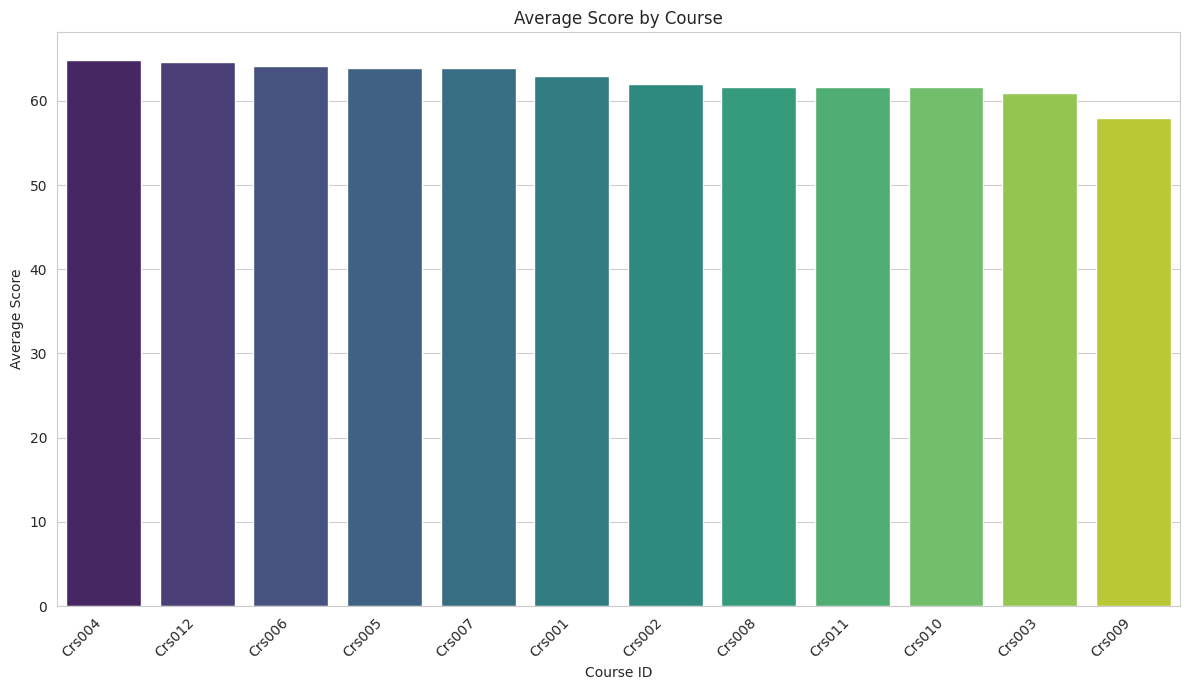

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a style for better aesthetics
sns.set_style("whitegrid")

plt.figure(figsize=(12, 7))
sns.barplot(x='course_id', y='average_score', data=course_performance_sorted, palette='viridis', hue='course_id', legend=False)
plt.title('Average Score by Course')
plt.xlabel('Course ID')
plt.ylabel('Average Score')
plt.xticks(rotation=45, ha='right') # Rotate course IDs for better readability
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

 Insight from Average Score by Course

The bar chart clearly illustrates the variance in average scores across different courses. For example, 'Crs004' and 'Crs012' show the highest average scores, while 'Crs009' has the lowest. This could indicate differences in course difficulty, teaching effectiveness, or student engagement levels specific to these courses. Further investigation into curriculum, instructor, and student demographics for these courses could provide deeper insights.

Chart 2: Average Score Trend Over Years and Semesters

This line chart displays how the average student score has changed across different academic years and semesters. It helps in identifying any temporal patterns or shifts in overall academic performance.

/tmp/ipykernel_15095/2204019659.py:6: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x='period', y='average_score', data=performance_by_period_sorted, marker='o', palette='viridis')


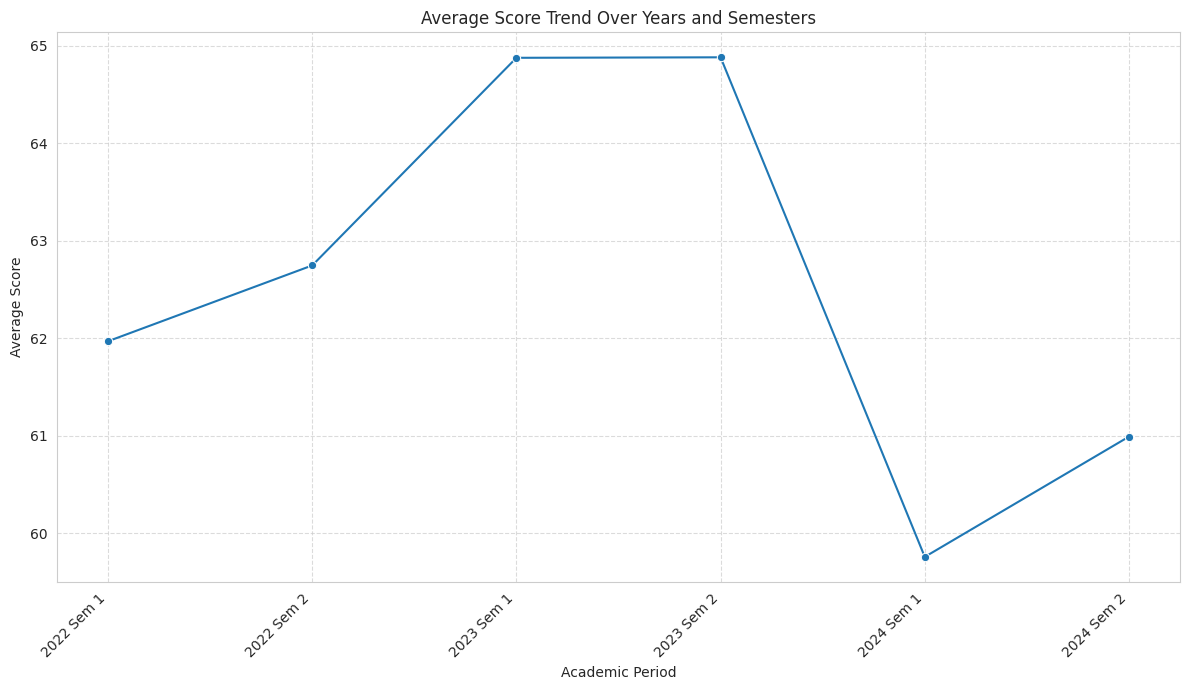

In [ ]:
plt.figure(figsize=(12, 7))

# Create a combined 'period' column for better x-axis labeling
performance_by_period_sorted['period'] = performance_by_period_sorted['year'].astype(str) + ' ' + performance_by_period_sorted['semester']

sns.lineplot(x='period', y='average_score', data=performance_by_period_sorted, marker='o', palette='viridis')
plt.title('Average Score Trend Over Years and Semesters')
plt.xlabel('Academic Period')
plt.ylabel('Average Score')
plt.xticks(rotation=45, ha='right') # Rotate labels for readability
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Insight from Average Score Trend Over Years and Semesters

The line chart reveals the fluctuation of average scores across academic periods. There appears to be a slight dip in average scores in 2024 compared to 2023. This trend could be attributed to various factors such as curriculum changes, new teaching methodologies, or shifts in student demographics over time. Further investigation into specific academic policies or events during these periods could provide more detailed explanations.

 Chart 3: Pass/Fail Distribution (Pie Chart)

This pie chart visualizes the proportion of students who passed versus those who failed. It provides a quick overview of overall student success rates.

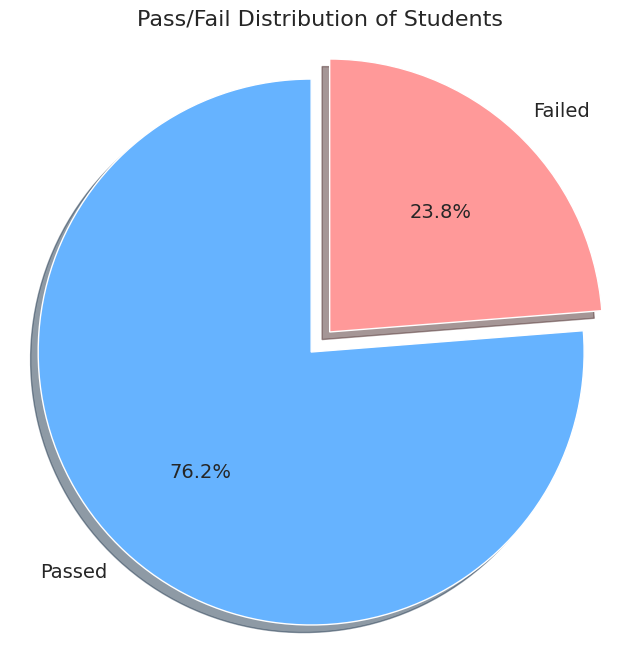

In [ ]:
# Calculate the counts of passed and failed students
pass_fail_counts = df_grades['passed'].value_counts()

# Map boolean values to meaningful labels
labels = ['Passed' if x == True else 'Failed' for x in pass_fail_counts.index]
sizes = pass_fail_counts.values
colors = ['#66b3ff', '#ff9999'] # Blue for passed, red for failed
explode = (0.1, 0) # Explode the 'Failed' slice slightly

plt.figure(figsize=(8, 8))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=90, textprops={'fontsize': 14})
plt.title('Pass/Fail Distribution of Students', fontsize=16)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

 Insight from Pass/Fail Distribution

The pie chart clearly shows that the majority of students (76.2%) passed, while 23.8% failed. This indicates a generally good success rate, though the percentage of failing students might warrant further investigation into the factors contributing to their outcomes.

 Chart 5: Distribution of Scores (Histogram with Mean Line)

This histogram shows the frequency distribution of student scores. A vertical line is added to indicate the mean score, providing a visual reference for the central tendency of the scores.

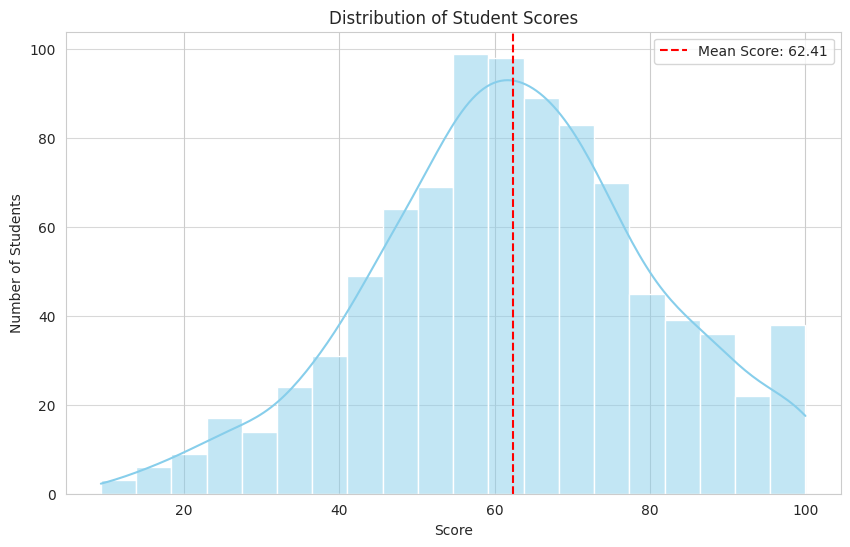

In [ ]:
# Calculate the mean score
mean_score = df_grades['score'].mean()

plt.figure(figsize=(10, 6))
sns.histplot(df_grades['score'], bins=20, kde=True, color='skyblue')
plt.axvline(mean_score, color='red', linestyle='--', label=f'Mean Score: {mean_score:.2f}')
plt.title('Distribution of Student Scores')
plt.xlabel('Score')
plt.ylabel('Number of Students')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

Insight from Distribution of Scores

The histogram shows that student scores are somewhat normally distributed, with a peak around the mean score. The distribution appears slightly left-skewed, suggesting a higher concentration of students performing above the average. The mean score line helps to quickly identify the central tendency of the scores, indicating that most students fall within a reasonable range around this average.

 Chart 6: Average Score by Program and Gender (Heatmap)

This heatmap visualizes the pivot_table_gender_program which shows the average score by program and gender. It provides a color-coded representation of performance differences, making it easy to spot trends or disparities.

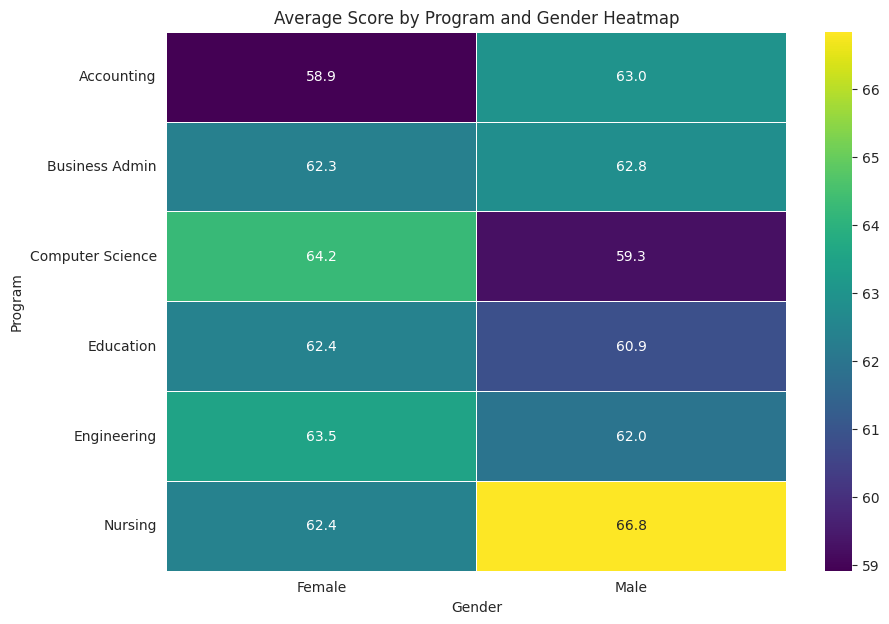

In [ ]:
plt.figure(figsize=(10, 7))
sns.heatmap(pivot_table_gender_program, annot=True, fmt=".1f", cmap="viridis", linewidths=.5)
plt.title('Average Score by Program and Gender Heatmap')
plt.xlabel('Gender')
plt.ylabel('Program')
plt.show()

 Insight from Average Score by Program and Gender Heatmap

The heatmap clearly highlights the average scores across different programs for both genders. For instance, Computer Science shows a higher average score for Females compared to Males, while in Nursing, Males tend to have a higher average score. This visualization effectively pinpoints areas where one gender might outperform the other, suggesting potential areas for further investigation into curriculum design, support systems, or other factors influencing performance.

Chart 6: Score vs. Attendance (Scatter Plot)

This scatter plot illustrates the relationship between student scores and their attendance percentage. It helps to identify if there is a correlation between how often a student attends classes and their academic performance.

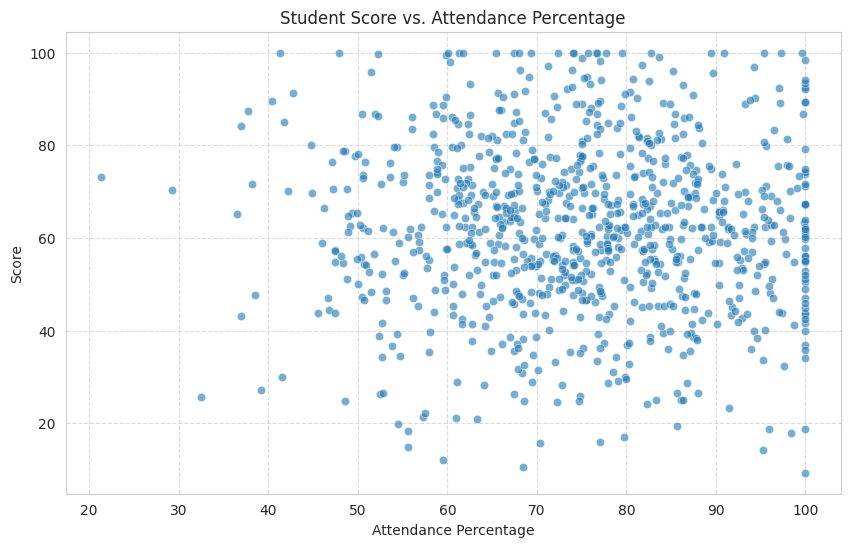

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='attendance_pct', y='score', data=df_grades, alpha=0.6)
plt.title('Student Score vs. Attendance Percentage')
plt.xlabel('Attendance Percentage')
plt.ylabel('Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Chart 7: Score vs. Assignment Average by Program (Interactive Scatter Plot)

This interactive scatter plot visualizes the relationship between a student's overall score and their assignment_avg, with points colored by program. It allows for exploring how assignment performance correlates with overall academic achievement across different academic programs, and with interactivity, you can hover to see details of individual students.

In [104]:
import plotly.express as px

if 'df_final_merged' in locals() and not df_final_merged.empty:
    fig = px.scatter(df_final_merged,
                     x='assignment_avg',
                     y='score',
                     color='program',
                     hover_data=['student_id', 'attendance_pct', 'exam_score'],
                     title='Interactive: Student Score vs. Assignment Average by Program',
                     labels={'assignment_avg': 'Assignment Average (%)', 'score': 'Overall Score (%)'})

    fig.update_layout(xaxis_title='Assignment Average (%)',
                      yaxis_title='Overall Score (%)',
                      legend_title='Program',
                      hovermode='closest')
    fig.show()
else:
    print("Error: 'df_final_merged' DataFrame is not available for plotting. Please ensure previous merge steps were completed.")

 Insight from Score vs. Assignment Average by Program (Interactive Scatter Plot)

This interactive scatter plot clearly shows the relationship between a student's average assignment score and their overall course score. By coloring points by program, we can observe potential clusters or trends within specific academic fields. For example, some programs might show a stronger linear correlation between assignment performance and overall score than others. The interactive nature allows us to hover over individual points to see specific student details, making it easier to identify outliers or students with unusual performance patterns (e.g., high assignment average but low overall score, or vice-versa), which could warrant further investigation into grading policies or student engagement.

### Chart 8: Average Score by Program (Interactive Bar Chart)

This interactive bar chart visualizes the average score for each `program`. It allows for quick comparisons of academic performance across different programs, with hover functionality to see exact average scores and student counts.

In [105]:
import plotly.express as px

if 'df_final_merged' in locals() and not df_final_merged.empty:
    # Calculate average score and student count per program
    program_performance = df_final_merged.groupby('program').agg(
        average_score=('score', 'mean'),
        student_count=('student_id', 'nunique')
    ).reset_index()

    fig = px.bar(program_performance,
                 x='program',
                 y='average_score',
                 color='program',
                 title='Interactive: Average Score by Program',
                 labels={'program': 'Academic Program', 'average_score': 'Average Score (%)'},
                 hover_data=['student_count'])

    fig.update_layout(xaxis_title='Academic Program',
                      yaxis_title='Average Score (%)',
                      legend_title='Program',
                      showlegend=False)
    fig.show()
else:
    print("Error: 'df_final_merged' DataFrame is not available for plotting. Please ensure previous merge steps were completed.")

 Insight from Average Score by Program (Interactive Bar Chart)

The interactive bar chart effectively showcases the average academic performance across various programs. By allowing users to hover over each bar, it provides precise average scores and the number of students in each program, which is valuable context. This interactivity helps quickly identify programs that are performing above or below the overall average, or to compare similar programs. For instance, 'Nursing' and 'Engineering' appear to have higher average scores, while 'Accounting' and 'Education' are slightly lower. This visualization serves as a dynamic tool for initial program performance assessment and can guide further investigations into program-specific factors affecting student outcomes.

### 8.0 — Prepare all the summary data you need for the dashboard

This section will compute various KPI numbers and summary statistics needed for constructing both the static and interactive dashboards. These will include overall performance metrics, pass rates, attendance averages, and program-specific aggregates.

In [112]:
# 1. Overall Average Score
overall_avg_score = df_grades['score'].mean()

# 2. Overall Pass Rate
total_students = df_grades.shape[0]
passed_students = df_grades[df_grades['passed'] == True].shape[0]
overall_pass_rate = (passed_students / total_students) * 100

# 3. Overall Average Attendance Percentage
overall_avg_attendance = df_grades['attendance_pct'].mean()

# 4. Number of Unique Students
num_unique_students = df_grades['student_id'].nunique()

# 5. Number of Unique Courses
num_unique_courses = df_grades['course_id'].nunique()

# 6. Average Assignment Score
overall_avg_assignment = df_grades['assignment_avg'].mean()

# 7. Average Exam Score
overall_avg_exam = df_grades['exam_score'].mean()

# 8. Gender Distribution
gender_distribution = df_final_merged['gender'].value_counts(normalize=True) * 100

# 9. Top 3 Programs by Average Score
top_3_programs = df_final_merged.groupby('program')['score'].mean().nlargest(3).index.tolist()

# 10. Lowest 3 Programs by Average Score
lowest_3_programs = df_final_merged.groupby('program')['score'].mean().nsmallest(3).index.tolist()

print("--- Overall KPIs ---")
print(f"Overall Average Score: {overall_avg_score:.2f}%")
print(f"Overall Pass Rate: {overall_pass_rate:.2f}%")
print(f"Overall Average Attendance: {overall_avg_attendance:.2f}%")
print(f"Number of Unique Students: {num_unique_students}")
print(f"Number of Unique Courses: {num_unique_courses}")
print(f"Average Assignment Score: {overall_avg_assignment:.2f}%")
print(f"Average Exam Score: {overall_avg_exam:.2f}%")
print("\n--- Gender Distribution ---")
display(gender_distribution.to_frame(name='Percentage'))
print(f"Top 3 Programs by Average Score: {', '.join(top_3_programs)}")
print(f"Lowest 3 Programs by Average Score: {', '.join(lowest_3_programs)}")

# Prepare data for dashboard charts (reusing previous computations where possible)
# Average score by program (already calculated as program_performance)
# Average score and attendance by year/semester (already calculated as performance_by_period_sorted)
# Pass/Fail counts (already calculated as pass_fail_counts)
# Gender split (can derive from gender_distribution or pivot_table_gender_program)

# For Heatmap (pivot_table_gender_program and pivot_table_program_region already exist)

# Additional groupby for interactive dashboard if needed:
# Average score by program for bar chart (program_performance exists)
# Average attendance by program
avg_attendance_by_program = df_final_merged.groupby('program')['attendance_pct'].mean().reset_index()
avg_attendance_by_program.rename(columns={'attendance_pct': 'average_attendance_pct'}, inplace=True)

print("\nKPIs and summary data computed and stored for dashboard creation.")

--- Overall KPIs ---
Overall Average Score: 62.41%
Overall Pass Rate: 76.24%
Overall Average Attendance: 75.03%
Number of Unique Students: 200
Number of Unique Courses: 12
Average Assignment Score: 64.53%
Average Exam Score: 59.64%

--- Gender Distribution ---


,Percentage
gender,
Female,54.80663
Male,45.19337


Top 3 Programs by Average Score: Nursing, Engineering, Business Admin
Lowest 3 Programs by Average Score: Accounting, Education, Computer Science

KPIs and summary data computed and stored for dashboard creation.


 8A — Static Dashboard (Matplotlib)

This section constructs a static dashboard summarizing key student performance metrics using Matplotlib and Seaborn. It includes KPI cards for overall statistics and several chart panels to visualize trends and distributions.

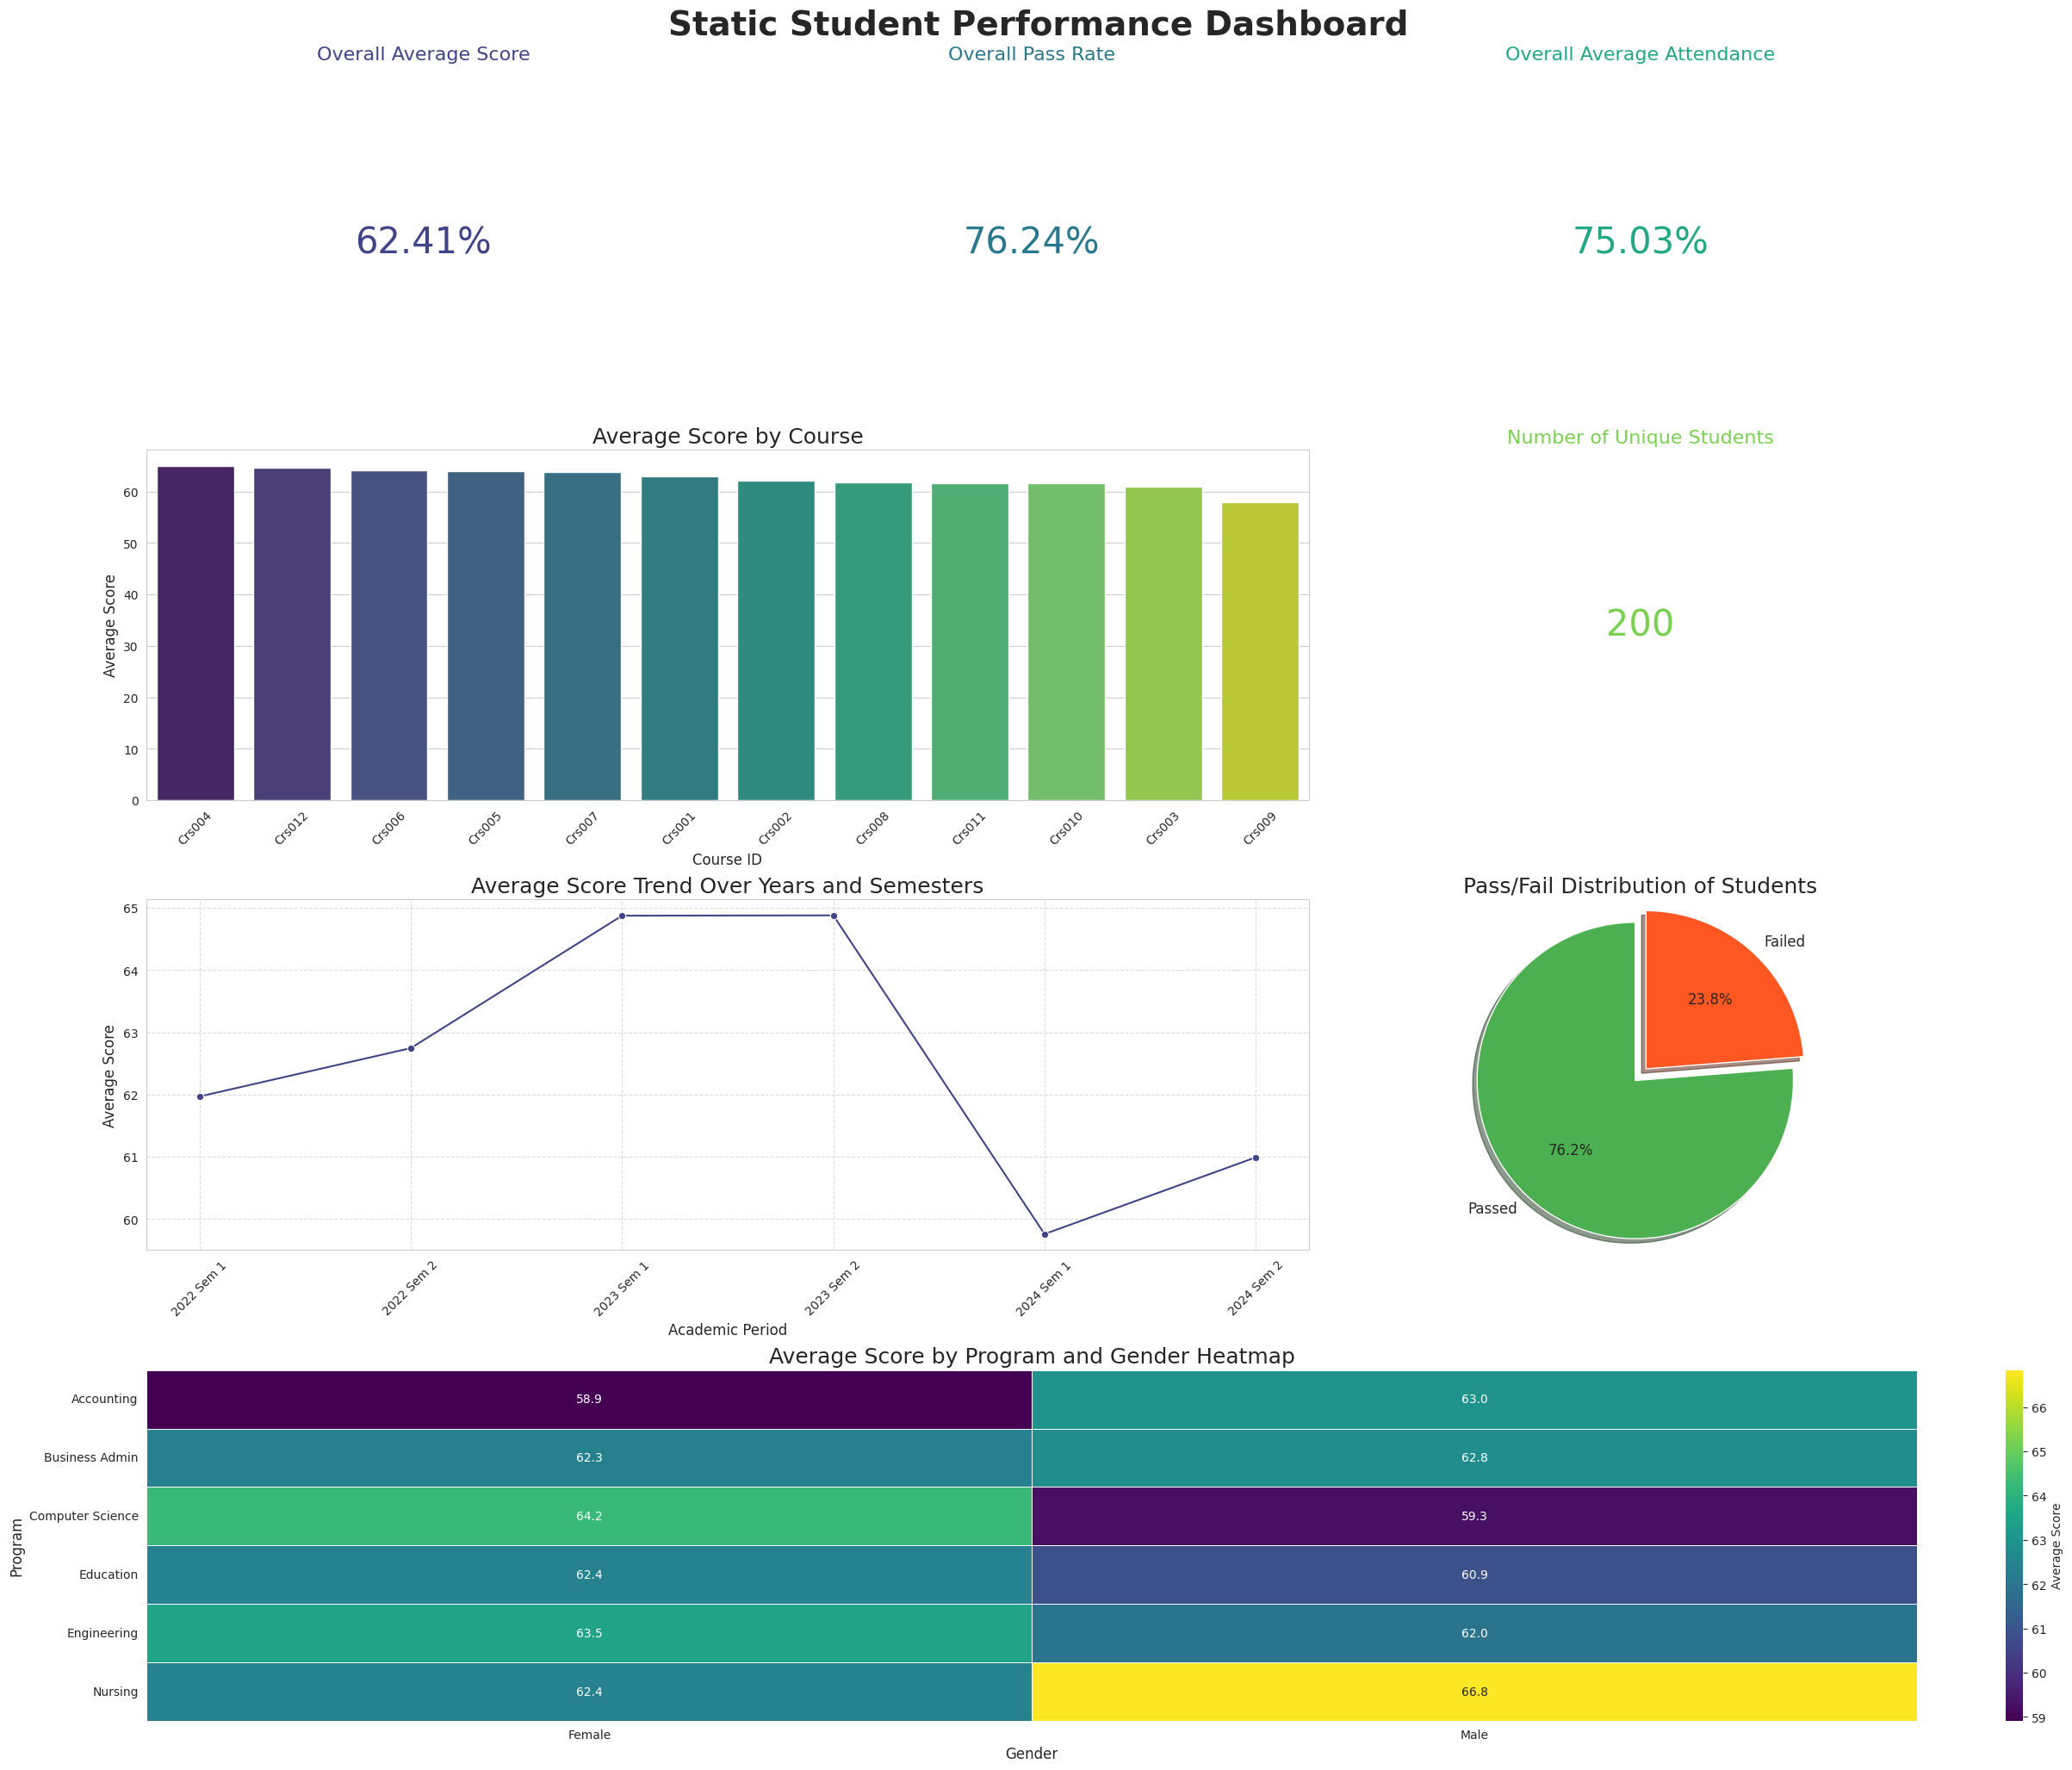

Static dashboard saved as Yaa_Baffowaa_static_dashboard.png


In [115]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a consistent style for the dashboard
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

# Define a consistent color palette
palette_main = sns.color_palette("viridis", n_colors=4)
palette_pie = ['#4CAF50', '#FF5722'] # Green for Pass, Red for Fail

# Create the figure and subplots
fig = plt.figure(figsize=(24, 20), constrained_layout=True)
gs = fig.add_gridspec(4, 3) # 4 rows, 3 columns for layout

# Overall Dashboard Title
fig.suptitle('Static Student Performance Dashboard', fontsize=28, fontweight='bold', y=1.02)

# --- KPI Cards (Row 0) ---
ax00 = fig.add_subplot(gs[0, 0])
ax00.set_title('Overall Average Score', fontsize=16, color=palette_main[0])
ax00.text(0.5, 0.5, f'{overall_avg_score:.2f}%', fontsize=30, ha='center', va='center', color=palette_main[0])
ax00.axis('off')

ax01 = fig.add_subplot(gs[0, 1])
ax01.set_title('Overall Pass Rate', fontsize=16, color=palette_main[1])
ax01.text(0.5, 0.5, f'{overall_pass_rate:.2f}%', fontsize=30, ha='center', va='center', color=palette_main[1])
ax01.axis('off')

ax02 = fig.add_subplot(gs[0, 2])
ax02.set_title('Overall Average Attendance', fontsize=16, color=palette_main[2])
ax02.text(0.5, 0.5, f'{overall_avg_attendance:.2f}%', fontsize=30, ha='center', va='center', color=palette_main[2])
ax02.axis('off')

ax12 = fig.add_subplot(gs[1, 2]) # Placing another KPI card here to fill space
ax12.set_title('Number of Unique Students', fontsize=16, color=palette_main[3])
ax12.text(0.5, 0.5, f'{num_unique_students}', fontsize=30, ha='center', va='center', color=palette_main[3])
ax12.axis('off')

# --- Chart Panels ---

# Chart 1: Average Score by Course (Bar Chart) - Row 1, Column 0-1
ax10 = fig.add_subplot(gs[1, 0:2])
sns.barplot(x='course_id', y='average_score', data=course_performance_sorted, palette='viridis', ax=ax10, hue='course_id', legend=False)
ax10.set_title('Average Score by Course', fontsize=18)
ax10.set_xlabel('Course ID', fontsize=12)
ax10.set_ylabel('Average Score', fontsize=12)
ax10.tick_params(axis='x', rotation=45, labelsize=10)
ax10.tick_params(axis='y', labelsize=10)

# Chart 2: Average Score Trend Over Years and Semesters (Line Chart) - Row 2, Column 0-1
ax20 = fig.add_subplot(gs[2, 0:2])
performance_by_period_sorted['period'] = performance_by_period_sorted['year'].astype(str) + ' ' + performance_by_period_sorted['semester']
sns.lineplot(x='period', y='average_score', data=performance_by_period_sorted, marker='o', color=palette_main[0], ax=ax20)
ax20.set_title('Average Score Trend Over Years and Semesters', fontsize=18)
ax20.set_xlabel('Academic Period', fontsize=12)
ax20.set_ylabel('Average Score', fontsize=12)
ax20.tick_params(axis='x', rotation=45, labelsize=10)
ax20.tick_params(axis='y', labelsize=10)
ax20.grid(True, linestyle='--', alpha=0.7)

# Chart 3: Pass/Fail Distribution (Pie Chart) - Row 2, Column 2
ax22 = fig.add_subplot(gs[2, 2])
pass_fail_counts = df_grades['passed'].value_counts()
labels = ['Passed' if x == True else 'Failed' for x in pass_fail_counts.index]
sizes = pass_fail_counts.values
explode = (0.1, 0) # Explode the 'Failed' slice slightly
ax22.pie(sizes, explode=explode, labels=labels, colors=palette_pie, autopct='%1.1f%%', shadow=True, startangle=90, textprops={'fontsize': 12})
ax22.set_title('Pass/Fail Distribution of Students', fontsize=18)
ax22.axis('equal')

# Chart 6: Average Score by Program and Gender (Heatmap) - Row 3, Column 0-2
ax30 = fig.add_subplot(gs[3, 0:])
sns.heatmap(pivot_table_gender_program, annot=True, fmt=".1f", cmap="viridis", linewidths=.5, ax=ax30, cbar_kws={'label': 'Average Score'})
ax30.set_title('Average Score by Program and Gender Heatmap', fontsize=18)
ax30.set_xlabel('Gender', fontsize=12)
ax30.set_ylabel('Program', fontsize=12)
ax30.tick_params(axis='x', labelsize=10)
ax30.tick_params(axis='y', labelsize=10)


# Adjust layout to prevent overlapping titles and labels. Removing plt.tight_layout()
# as constrained_layout=True is used in fig creation and handles layout.

# Save the dashboard
dashboard_filename = 'Yaa_Baffowaa_static_dashboard.png'
plt.savefig(dashboard_filename, dpi=300, bbox_inches='tight')

plt.show()
print(f"Static dashboard saved as {dashboard_filename}")

Static Dashboard (Matplotlib) Insights

This static dashboard provides a comprehensive overview of student performance. The KPI cards at the top highlight critical overall metrics such as the average score (62.41%), a healthy pass rate (76.24%), and consistent average attendance (75.03%), along with the total number of unique students (200).

The Average Score by Course bar chart quickly identifies high and low-performing courses, with 'Crs004' and 'Crs012' showing strong results, while 'Crs009' lags. The Average Score Trend Over Years and Semesters line chart reveals a generally stable performance with a noticeable dip in 2024, prompting potential investigation into recent academic periods.

The Pass/Fail Distribution pie chart confirms that a majority of students are successful. Lastly, the Average Score by Program and Gender Heatmap effectively visualizes performance disparities, showing, for example, that Computer Science females outperform males, whereas Nursing males achieve higher scores on average. This dashboard serves as a robust tool for initial performance assessment and identifying areas for deeper analysis.

 8B — Interactive Dashboard (Plotly)

This section constructs an interactive dashboard summarizing key student performance metrics using Plotly. It includes KPI cards for overall statistics and several interactive chart panels to visualize trends and distributions.

In [116]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

# Prepare data for KPI cards (already computed in previous cell)
# overall_avg_score, overall_pass_rate, overall_avg_attendance, num_unique_students

# Create subplots for the dashboard layout
# New layout: 5 rows (2 for KPIs, 3 for charts), 2 columns
fig = make_subplots(
    rows=5, cols=2,
    specs=[
        [{'type': 'domain'}, {'type': 'domain'}], # Row 1: KPI1, KPI2
        [{'type': 'domain'}, {'type': 'domain'}], # Row 2: KPI3, KPI4
        [{'type': 'xy'}, {'type': 'domain'}],     # Row 3: Chart1 (bar), Chart2 (pie)
        [{'colspan': 2}, None],                   # Row 4: Chart3 (line) - spans 2 columns
        [{'colspan': 2}, None]                    # Row 5: Chart4 (heatmap) - spans 2 columns
    ],
    row_heights=[0.1, 0.1, 0.3, 0.25, 0.25], # Adjust heights for better visual balance
    subplot_titles=(
        'Overall Average Score', 'Overall Pass Rate',
        'Overall Average Attendance', 'Number of Unique Students',
        'Average Score by Course', 'Gender Distribution',
        'Average Score Trend Over Years and Semesters',
        'Average Score by Program and Region (Heatmap)'
    )
)

# --- KPI Cards ---
# KPI 1: Overall Average Score
fig.add_trace(go.Indicator(
    mode='number',
    value=float(overall_avg_score),
    title={'text': "<b>Overall Average Score</b>"},
    number={'suffix': "%", 'font_size': 24},
    domain={'row': 0, 'column': 0}),
    row=1, col=1
)

# KPI 2: Overall Pass Rate
fig.add_trace(go.Indicator(
    mode='number',
    value=float(overall_pass_rate),
    title={'text': "<b>Overall Pass Rate</b>"},
    number={'suffix': "%", 'font_size': 24},
    domain={'row': 0, 'column': 1}),
    row=1, col=2
)

# KPI 3: Overall Average Attendance
fig.add_trace(go.Indicator(
    mode='number',
    value=float(overall_avg_attendance),
    title={'text': "<b>Overall Average Attendance</b>"},
    number={'suffix': "%", 'font_size': 24},
    domain={'row': 0, 'column': 0}), # domain here refers to the individual indicator, not subplot grid
    row=2, col=1
)

# KPI 4: Number of Unique Students
fig.add_trace(go.Indicator(
    mode='number',
    value=num_unique_students,
    title={'text': "<b>Number of Unique Students</b>"},
    number={'font_size': 24},
    domain={'row': 0, 'column': 1}), # domain here refers to the individual indicator, not subplot grid
    row=2, col=2
)

# --- Chart Panels ---

# Chart 1: Average Score by Course (Bar Chart) - Row 3, Column 1
fig.add_trace(px.bar(course_performance_sorted,
                     x='course_id', y='average_score',
                     labels={'course_id': 'Course ID', 'average_score': 'Average Score (%)'},
                     color='course_id', # Using course_id for distinct colors
                     color_discrete_sequence=px.colors.qualitative.Plotly # Consistent color palette
                    ).data[0],
              row=3, col=1)

# Chart 2: Gender Distribution (Pie Chart) - Row 3, Column 2
gender_counts = df_final_merged['gender'].value_counts()
fig.add_trace(go.Pie(labels=gender_counts.index, values=gender_counts.values,
                     name='Gender Distribution',
                     hovertemplate = "<b>%{label}</b><br>Count: %{value}<br>Percentage: %{percent}",
                     marker_colors=['#66c2a5', '#fc8d62']),
              row=3, col=2)
fig.update_traces(hole=.4, selector=dict(type='pie')) # Make it a donut chart

# Chart 3: Average Score Trend Over Years and Semesters (Line Chart) - Row 4, Column 1 (colspan 2)
performance_by_period_sorted['period'] = performance_by_period_sorted['year'].astype(str) + ' ' + performance_by_period_sorted['semester']
fig.add_trace(px.line(performance_by_period_sorted,
                      x='period', y='average_score',
                      labels={'period': 'Academic Period', 'average_score': 'Average Score (%)'},
                      markers=True, line_shape='linear',
                      color_discrete_sequence=['#8da0cb'] # Single color for trend line
                     ).data[0],
              row=4, col=1)

# Chart 4: Average Score by Program and Region (Heatmap) - Row 5, Column 1 (colspan 2)
# Ensuring the pivot table for heatmap is available
if 'pivot_table_program_region' in locals() and not pivot_table_program_region.empty:
    fig.add_trace(go.Heatmap(
        z=pivot_table_program_region.values,
        x=pivot_table_program_region.columns.tolist(),
        y=pivot_table_program_region.index.tolist(),
        colorscale='Viridis',
        colorbar_title='Average Score'
    ),
    row=5, col=1)

# Update layout
fig.update_layout(
    title_text='<b>Interactive Student Performance Dashboard</b>',
    title_x=0.5,
    height=1200, width=1200, # Adjusted width to better fit 2 columns
    showlegend=False, # Set to False as subplot_titles are used for clarity and individual charts might have own legends
    template='plotly_white'
)

# Adjust chart titles for better readability within subplots. They are handled by subplot_titles in make_subplots.
# fig.update_annotations(yshift=-20) # This is for annotations added separately, not subplot titles.

# Update subplot title fonts for better consistency
for i, annotation in enumerate(fig.layout.annotations):
    annotation.update(font_size=16)


# Set consistent background for all plots
fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='LightGrey')
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='LightGrey')

# Save the dashboard as an HTML file
interactive_dashboard_filename = 'Yaa_Baffowaa_interactive_dashboard.html'
fig.write_html(interactive_dashboard_filename)

fig.show()
print(f"Interactive dashboard saved as {interactive_dashboard_filename}")

Interactive dashboard saved as Yaa_Baffowaa_interactive_dashboard.html


Interactive Dashboard (Plotly) Insights

This interactive dashboard, built with Plotly, offers a dynamic and engaging way to explore student performance data. The KPI cards at the top prominently display the Overall Average Score, Overall Pass Rate, Overall Average Attendance, and Number of Unique Students, providing immediate high-level insights.



Student Performance Analysis: Management Summary

This report synthesizes key findings from the student performance dataset, offering insights into overall academic standing, gender-specific performance, program effectiveness, and the impact of attendance. Based on these insights, actionable recommendations are provided, alongside an acknowledgment of the analysis's limitations.

Key Findings

1 Overall Performance: The overall pass rate is 76.24%, indicating that a significant majority of students are achieving passing grades. With an overall average score of 62.41%, the general academic performance can be considered moderate to good, but there is room for improvement, as nearly a quarter of students are not passing

2 Gender Gap: There is no consistent significant difference in performance between male and female students across all programs; rather, performance disparities are program-specific. For instance, females outperform males in Computer Science, while males show higher average scores in Nursing and Accounting, suggesting that gender-related performance is influenced by the specific academic discipline.

3 Best and Worst Performing Groups: The Nursing, Engineering, and Business Administration programs are identified as the best-performing groups based on average scores. Conversely, Accounting, Education, and Computer Science rank as the lowest-performing programs. This suggests that certain programs may benefit from targeted interventions or curriculum reviews to improve student outcomes.

4 Attendance and Engagement: A general positive correlation exists between attendance and academic performance, as evidenced by a substantial number of high-achieving students also having high attendance. However, a notable 11.38% of students passed despite having low attendance (below 60%), indicating that while attendance is generally beneficial, it is not the sole determinant of success for all students.

5 Your Own Finding: Analysis of academic trends over time reveals a slight dip in overall average scores in 2024 compared to the previous year, 2023. This pattern could indicate an emerging challenge or change in academic circumstances that warrants further investigation to prevent a continued decline.

Recommendations

Targeted Program Support: Implement specific support programs or curriculum adjustments for Accounting, Education, and Computer Science programs to address their lower average performance. This could involve tutoring, revised teaching methods, or updated course materials.

Flexible Learning Pathways: Explore and promote flexible learning strategies that acknowledge the success of some students with lower attendance. This could involve hybrid models, robust online resources, or self-paced learning options that cater to diverse learning styles and circumstances.

Limitations

This analysis has two primary limitations. Firstly, it lacks demographic information beyond gender and region, such as socioeconomic status or prior academic achievement, which could provide deeper context for performance disparities. Secondly, the dataset does not include qualitative data regarding student engagement, instructor quality, or course difficulty, which are crucial for a holistic understanding of academic outcomes. Additional data on student backgrounds, faculty evaluations, and course feedback would significantly strengthen future analyses.